In [2]:
import os
import kagglehub

os.environ['KAGGLEHUB_CACHE_DIR'] = "/content/kaggle_datasets"

download_path = kagglehub.dataset_download('tolgadincer/labeled-chest-xray-images')

print(download_path)

Using Colab cache for faster access to the 'labeled-chest-xray-images' dataset.
/kaggle/input/labeled-chest-xray-images


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold

N_SPLITS = 5
# path = '/root/.cache/kagglehub/datasets/tolgadincer/labeled-chest-xray-images/versions/1/chest_xray/'
path = '/kaggle/input/labeled-chest-xray-images/chest_xray/'

train_dir = os.path.join(path, 'train')
test_dir = os.path.join(path, 'test')
categories = ['NORMAL', 'PNEUMONIA']

label_to_idx = {'NORMAL': 0, 'PNEUMONIA': 1}

train_val_data = []
for category in categories:
    folder_path = os.path.join(train_dir, category)
    for image_name in os.listdir(folder_path):
        if image_name.endswith(('jpg', 'jpeg', 'png')):

            if '_' in image_name:
                patient_id = image_name.split('_')[0]
            elif '-' in image_name:
                patient_id = image_name.rsplit('-', 1)[0]
            else:
                patient_id = image_name.split('.')[0]

            train_val_data.append({
                'image_path': os.path.join(folder_path, image_name),
                'label_name': category,
                'patient_id': patient_id
            })

train_val_df = pd.DataFrame(train_val_data)
train_val_df['label'] = train_val_df['label_name'].map(label_to_idx)

test_data = []
for category in categories:
    folder_path = os.path.join(test_dir, category)
    for image_name in os.listdir(folder_path):
        if image_name.endswith(('jpg', 'jpeg', 'png')):

            if '_' in image_name:
                patient_id = image_name.split('_')[0]
            elif '-' in image_name:
                patient_id = image_name.rsplit('-', 1)[0]
            else:
                patient_id = image_name.split('.')[0]

            test_data.append({
                'image_path': os.path.join(folder_path, image_name),
                'label_name': category,
                'patient_id': patient_id
            })

test_df = pd.DataFrame(test_data)
test_df['label'] = test_df['label_name'].map(label_to_idx)

train_val_df['fold'] = -1
sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X=train_val_df, y=train_val_df['label'], groups=train_val_df['patient_id'])):
    train_val_df.loc[val_idx, 'fold'] = fold

print(f"전체 Train/Val 이미지 수: {len(train_val_df)}장 | 고유 환자 수: {train_val_df['patient_id'].nunique()}명")
print(f"최종 Test 이미지 수: {len(test_df)}장")

for fold in range(N_SPLITS):
    f_val = train_val_df[train_val_df['fold'] == fold]
    print(f"Fold {fold} -> 데이터: {len(f_val)}장 | 정상: {(f_val['label']==0).sum()}장, 폐렴: {(f_val['label']==1).sum()}장")

전체 Train/Val 이미지 수: 5232장 | 고유 환자 수: 3458명
최종 Test 이미지 수: 624장
Fold 0 -> 데이터: 990장 | 정상: 263장, 폐렴: 727장
Fold 1 -> 데이터: 1045장 | 정상: 276장, 폐렴: 769장
Fold 2 -> 데이터: 1078장 | 정상: 268장, 폐렴: 810장
Fold 3 -> 데이터: 1081장 | 정상: 290장, 폐렴: 791장
Fold 4 -> 데이터: 1038장 | 정상: 252장, 폐렴: 786장


In [4]:
import cv2
import torch
from torch.utils.data import Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2

class ChestXrayBCEDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = cv2.imread(row['image_path'])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        label = float(row['label'])
        label_tensor = torch.tensor([label], dtype=torch.float32)

        return image, label_tensor

train_transform = A.Compose([
    A.Resize(224, 224),# 👈 128에서 224로 벌크업!
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2), # 20% 확률로 밝기와 명암 조절
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=10, p=0.5), # 미세한 회전 및 삐딱함 방어
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_test_transform = A.Compose([
    A.Resize(224, 224),# 👈 128에서 224로 벌크업!
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [5]:
import torch.nn as nn
from torch.utils.data import DataLoader
import timm
from sklearn.metrics import f1_score
from torch.optim.lr_scheduler import CosineAnnealingLR
import torchvision.models as models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
epochs = 3
BATCH_SIZE = 64
LR = 1e-3

test_dataset = ChestXrayBCEDataset(df=test_df, transform=val_test_transform)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

total_test_preds = torch.zeros(len(test_df), 1).to(device)

for fold in range(N_SPLITS):
    train_data = train_val_df[train_val_df['fold'] != fold].reset_index(drop=True)
    val_data = train_val_df[train_val_df['fold'] == fold].reset_index(drop=True)

    train_dataset = ChestXrayBCEDataset(df=train_data, transform=train_transform)
    train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

    val_dataset = ChestXrayBCEDataset(df=val_data, transform=val_test_transform)
    val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    # model = timm.create_model('resnet18', pretrained=True, num_classes=1).to(device)
    model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

    # 중요: resnet34의 마지막 레이어(FC)의 입력 차원을 동적으로 받아서 가공
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 1)

    model = model.to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

    # eta_min=1e-6: 학습률을 아무리 줄여도 최소 0.000001 밑으로는 떨어뜨리지 않겠다는 마지노선 설정.
    scheduler = CosineAnnealingLR(optimizer, T_max=3, eta_min=1e-6)

    best_val_f1 = 0.0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_preds_list, train_labels_list = [], []

        for images, labels in train_dataloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

            preds = (outputs > 0).float()

            train_preds_list.extend(preds.cpu().numpy())
            train_labels_list.extend(labels.cpu().numpy())

        epoch_train_loss = train_loss / len(train_data)
        epoch_train_f1 = f1_score(train_labels_list, train_preds_list, average='binary')

        model.eval()
        val_loss = 0.0
        val_preds_list, val_labels_list = [], []

        with torch.no_grad():
            for images, labels in val_dataloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)

                preds = (outputs > 0).float()

                val_preds_list.extend(preds.cpu().numpy())
                val_labels_list.extend(labels.cpu().numpy())

        epoch_val_loss = val_loss / len(val_data)
        epoch_val_f1 = f1_score(val_labels_list, val_preds_list, average='binary')

        print(f"Epoch {epoch+1} | Train Loss: {epoch_train_loss:.4f}, Train F1: {epoch_train_f1*100:.2f}%" \
              f" | Val Loss: {epoch_val_loss:.4f}, Val F1: {epoch_val_f1*100:.2f}%")


        if epoch_val_f1 > best_val_f1:
            best_val_f1 = epoch_val_f1
            torch.save(model.state_dict(), f"bce_best_model_fold{fold}.pth")

        scheduler.step()
        # 디버깅용 로그 프린트(현재 보폭이 얼마로 줄었는지 눈으로 확인하기)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Next Epoch Learning Rate updated to: {current_lr:.6f}")

    print(f"--> Load Best Model of Fold {fold} (Val F1: {best_val_f1*100:2f}%) and Predict Test Data")

    # best_model = timm.create_model('resnet18', pretrained=True, num_classes=1).to(device)
    # best_model.load_state_dict(torch.load(f"bce_best_model_fold{fold}.pth", map_location=device))

    best_model = models.resnet34(weights=None)

    num_ftrs = best_model.fc.in_features
    best_model.fc = nn.Linear(num_ftrs, 1)

    best_model = best_model.to(device)

    best_model.load_state_dict(torch.load(f"bce_best_model_fold{fold}.pth", map_location=device))

    best_model.eval()

    fold_test_preds = []
    with torch.no_grad():
        for images, _ in test_dataloader:
            images = images.to(device)
            outputs = best_model(images)

            probs = torch.sigmoid(outputs)
            fold_test_preds.append(probs)

    total_test_preds += torch.cat(fold_test_preds, 0)

final_test_probs = total_test_preds / N_SPLITS

final_classes = (final_test_probs > 0.5).int().cpu().numpy().flatten()

test_df['predicted_label'] = final_classes
test_df.to_csv('bce_submission.csv', index=False)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 200MB/s]


Epoch 1 | Train Loss: 0.1620, Train F1: 95.46% | Val Loss: 0.0689, Val F1: 98.32%
Next Epoch Learning Rate updated to: 0.000750
Epoch 2 | Train Loss: 0.0658, Train F1: 98.34% | Val Loss: 0.0546, Val F1: 98.70%
Next Epoch Learning Rate updated to: 0.000251
Epoch 3 | Train Loss: 0.0535, Train F1: 98.70% | Val Loss: 0.0365, Val F1: 99.18%
Next Epoch Learning Rate updated to: 0.000001
--> Load Best Model of Fold 0 (Val F1: 99.179207%) and Predict Test Data
Epoch 1 | Train Loss: 0.1570, Train F1: 95.70% | Val Loss: 0.7454, Val F1: 76.96%
Next Epoch Learning Rate updated to: 0.000750
Epoch 2 | Train Loss: 0.0888, Train F1: 97.68% | Val Loss: 0.0870, Val F1: 97.67%
Next Epoch Learning Rate updated to: 0.000251
Epoch 3 | Train Loss: 0.0510, Train F1: 98.74% | Val Loss: 0.0260, Val F1: 99.22%
Next Epoch Learning Rate updated to: 0.000001
--> Load Best Model of Fold 1 (Val F1: 99.216710%) and Predict Test Data
Epoch 1 | Train Loss: 0.1585, Train F1: 95.55% | Val Loss: 0.1352, Val F1: 97.30%
Next

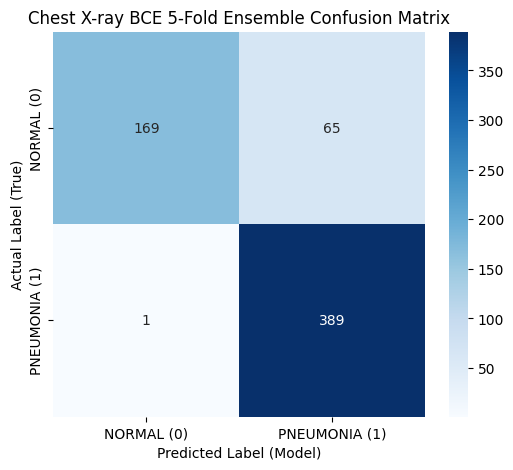

              precision    recall  f1-score   support

      NORMAL       0.99      0.72      0.84       234
   PNEUMONIA       0.86      1.00      0.92       390

    accuracy                           0.89       624
   macro avg       0.93      0.86      0.88       624
weighted avg       0.91      0.89      0.89       624



In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

try:
    df = pd.read_csv('bce_submission.csv')
except FileNotFoundError:
    df = test_df.copy()

y_true = df['label'].values
y_pred = df['predicted_label'].values

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL (0)', 'PNEUMONIA (1)'],
            yticklabels=['NORMAL (0)', 'PNEUMONIA (1)'])

plt.title('Chest X-ray BCE 5-Fold Ensemble Confusion Matrix')
plt.ylabel('Actual Label (True)')
plt.xlabel('Predicted Label (Model)')
plt.show()

print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))